# Notebook 14 — Subject-Wise 5-Fold Cross-Validation

### Steps 1–12 | Binary stress classification | Engineered features

**Why a new notebook?**  
Notebooks 12 & 13 use a random 70/30 split — meaning **windows from the same subject appear in both train and test**, which inflates all metrics. This notebook fixes that with a proper **subject-level KFold** and fits the scaler **inside each fold** to eliminate data leakage entirely.


In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve, auc
)

os.makedirs("../results/tables",  exist_ok=True)
os.makedirs("../results/figures", exist_ok=True)

print("All imports OK")

All imports OK


## Step 1 — Load data & verify required columns


In [2]:
# Step 1 ─ Load the engineered CSV and confirm every required column is present
df = pd.read_csv("../data/processed/windows_features_engineered.csv")

REQUIRED = ["Subject", "Stress_State",
            "Mean_RR", "SDNN", "RMSSD", "Mean_HR",
            "Resp_Rate", "Resp_Variability",
            "HRV_HR_Ratio", "Resp_Regularity", "Autonomic_Index"]

missing = [c for c in REQUIRED if c not in df.columns]
assert not missing, f"Missing columns: {missing}"

print(f"Shape        : {df.shape}")
print(f"Columns      : {df.columns.tolist()}")
df.head()

Shape        : (599, 13)
Columns      : ['Subject', 'Label', 'Mean_RR', 'SDNN', 'RMSSD', 'Mean_HR', 'Resp_Rate', 'Resp_Variability', 'Data_Source', 'Stress_State', 'HRV_HR_Ratio', 'Resp_Regularity', 'Autonomic_Index']


,Subject,Label,Mean_RR,SDNN,RMSSD,Mean_HR,Resp_Rate,Resp_Variability,Data_Source,Stress_State,HRV_HR_Ratio,Resp_Regularity,Autonomic_Index
0,S10,1,0.725557,0.144507,0.140624,82.695032,79.5,3.347959,Real,0,0.001701,0.298689,-82.409901
1,S10,1,0.685781,0.128872,0.082190,87.491522,103.5,3.421302,Real,0,0.000939,0.292286,-87.280459
2,S10,1,0.859689,0.261279,0.266298,69.792645,100.0,1.961128,Real,0,0.003816,0.509910,-69.265068
3,S10,1,0.887569,0.233748,0.249909,67.600356,124.5,2.406354,Real,0,0.003697,0.415566,-67.116699
4,S10,1,0.674756,0.147010,0.171729,88.920967,90.0,2.351720,Real,0,0.001931,0.425220,-88.602229


## Step 2 — Confirm binary label encoding & zero NaNs


In [3]:
# Step 2 ─ Stress_State is already binary: 0 = Non-Stress, 1 = Stress
#           Rename columns to standardised names used throughout this notebook

df = df.rename(columns={"Subject": "subject_id", "Stress_State": "label"})

# 2a. Confirm binary
unique_labels = sorted(df["label"].unique().tolist())
print(f"Unique label values : {unique_labels}")
assert unique_labels == [0, 1], "Labels must be exactly 0 and 1"

# 2b. Zero NaNs
FEATURE_COLS = [
    "Mean_RR", "SDNN", "RMSSD", "Mean_HR",
    "Resp_Rate", "Resp_Variability",
    "HRV_HR_Ratio", "Resp_Regularity", "Autonomic_Index"
]

nan_features = df[FEATURE_COLS].isnull().sum().sum()
nan_labels   = df["label"].isnull().sum()
print(f"NaNs in features    : {nan_features}")
print(f"NaNs in label       : {nan_labels}")
assert (nan_features + nan_labels) == 0, "Fix NaNs before proceeding"

# 2c. Label distribution
counts = df["label"].value_counts().sort_index()
print(f"\nLabel distribution:")
print(f"  Non-Stress (0) : {counts[0]}  ({counts[0]/len(df)*100:.1f}%)")
print(f"  Stress     (1) : {counts[1]}  ({counts[1]/len(df)*100:.1f}%)")

Unique label values : [0, 1]
NaNs in features    : 0
NaNs in label       : 0

Label distribution:
  Non-Stress (0) : 417  (69.6%)
  Stress     (1) : 182  (30.4%)


## Steps 3 & 4 — Extract X, y and unique subject IDs


In [4]:
# Step 3 ─ X = feature matrix, y = binary label, subject_id kept separate
X_full   = df[FEATURE_COLS].values       # shape (599, 9)
y_full   = df["label"].values            # shape (599,)  — 0 / 1
subjects = df["subject_id"].values       # shape (599,)  — e.g. 'S10'

# Step 4 ─ Unique subjects — these are the *units* we fold over, not windows
unique_subjects = np.unique(subjects)

print(f"Total windows  : {len(X_full)}")
print(f"Feature columns: {len(FEATURE_COLS)}")
print(f"Total subjects : {len(unique_subjects)}")
print(f"Subject IDs    : {unique_subjects}")

Total windows  : 599
Feature columns: 9
Total subjects : 15
Subject IDs    : ['S10' 'S11' 'S13' 'S14' 'S15' 'S16' 'S17' 'S2' 'S3' 'S4' 'S5' 'S6' 'S7'
 'S8' 'S9']


## Steps 5 & 6 — Subject-wise KFold splitter & per-fold metric containers


In [5]:
# Step 5 ─ KFold over subjects (not over individual windows)
#           shuffle=True so subjects are randomised before splitting
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Step 6 ─ One empty list per metric, per model
MODEL_NAMES = ["Logistic Regression", "SVM (RBF Kernel)", "Random Forest"]

fold_metrics = {
    name: {"accuracy":[], "precision":[], "recall":[], "f1":[], "roc_auc":[]}
    for name in MODEL_NAMES
}

# Storage for optional confusion-matrix + ROC curve aggregation (Steps 9 & 10)
all_y_test  = {name: [] for name in MODEL_NAMES}
all_y_pred  = {name: [] for name in MODEL_NAMES}
all_y_prob  = {name: [] for name in MODEL_NAMES}

# Storage for Random Forest feature importances (one array per fold)
rf_fold_importances = []   # each entry shape: (n_features,)

print("KFold splitter ready — splitting", len(unique_subjects), "subjects into 5 folds")
print("Metric containers initialised for:", MODEL_NAMES)

KFold splitter ready — splitting 15 subjects into 5 folds
Metric containers initialised for: ['Logistic Regression', 'SVM (RBF Kernel)', 'Random Forest']


## Step 7 — 5-Fold Cross-Validation Loop (Steps 7.1 – 7.12)


In [6]:
# Step 7 ─ Main subject-wise cross-validation loop
# ─────────────────────────────────────────────────────────────────────────────
# One fresh model definition per fold to guarantee no state carries over

for fold_idx, (train_subj_idx, test_subj_idx) in enumerate(kf.split(unique_subjects), start=1):

    # 7.1 ── Subject IDs for this fold
    train_subjects = unique_subjects[train_subj_idx]
    test_subjects  = unique_subjects[test_subj_idx]

    # 7.2 ── Build train / test DataFrames by filtering on subject_id
    train_mask = np.isin(subjects, train_subjects)
    test_mask  = np.isin(subjects, test_subjects)

    # 7.3 ── Split into X / y (subject_id already excluded from X_full)
    X_train, y_train = X_full[train_mask], y_full[train_mask]
    X_test,  y_test  = X_full[test_mask],  y_full[test_mask]

    # 7.4 ── Fit scaler on train only — prevents leakage into test
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)

    # 7.5 ── Apply the fitted scaler to test (transform only, never fit)
    X_test  = scaler.transform(X_test)

    # 7.6 ── Model definitions (fresh instances each fold)
    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        "SVM (RBF Kernel)"  : SVC(kernel="rbf", probability=True, random_state=42),
        "Random Forest"      : RandomForestClassifier(n_estimators=300, random_state=42),
    }

    print(f"\nFold {fold_idx}  |  train subjects: {train_subjects}  |  test subjects: {test_subjects}")
    print(f"         |  train windows : {len(X_train)}   |  test windows : {len(X_test)}")

    for name, model in models.items():

        # 7.7 ── Train
        model.fit(X_train, y_train)

        # Capture RF importances for this fold (used in feature importance section)
        if name == "Random Forest":
            rf_fold_importances.append(model.feature_importances_)

        # 7.8 ── Predict class labels
        y_pred = model.predict(X_test)

        # 7.9 ── Predict probabilities (positive class = 1 = Stress)
        y_prob = model.predict_proba(X_test)[:, 1]

        # 7.10 ── Per-fold metrics  (positive_label=1 means Stress is the positive class)
        acc  = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
        rec  = recall_score(y_test, y_pred,    pos_label=1, zero_division=0)
        f1   = f1_score(y_test, y_pred,         pos_label=1, zero_division=0)

        # 7.11 ── ROC-AUC
        roc  = roc_auc_score(y_test, y_prob)

        # 7.12 ── Append to lists
        fold_metrics[name]["accuracy"].append(acc)
        fold_metrics[name]["precision"].append(prec)
        fold_metrics[name]["recall"].append(rec)
        fold_metrics[name]["f1"].append(f1)
        fold_metrics[name]["roc_auc"].append(roc)

        # Store for aggregated CM + ROC (Steps 9 & 10)
        all_y_test[name].extend(y_test.tolist())
        all_y_pred[name].extend(y_pred.tolist())
        all_y_prob[name].extend(y_prob.tolist())

print("\n✓ Cross-validation complete")


Fold 1  |  train subjects: ['S11' 'S13' 'S14' 'S15' 'S16' 'S17' 'S2' 'S3' 'S5' 'S7' 'S8' 'S9']  |  test subjects: ['S10' 'S4' 'S6']
         |  train windows : 480   |  test windows : 119

Fold 2  |  train subjects: ['S10' 'S11' 'S13' 'S14' 'S15' 'S17' 'S2' 'S4' 'S5' 'S6' 'S7' 'S9']  |  test subjects: ['S16' 'S3' 'S8']
         |  train windows : 479   |  test windows : 120

Fold 3  |  train subjects: ['S10' 'S14' 'S15' 'S16' 'S17' 'S2' 'S3' 'S4' 'S5' 'S6' 'S7' 'S8']  |  test subjects: ['S11' 'S13' 'S9']
         |  train windows : 479   |  test windows : 120

Fold 4  |  train subjects: ['S10' 'S11' 'S13' 'S14' 'S16' 'S17' 'S3' 'S4' 'S6' 'S7' 'S8' 'S9']  |  test subjects: ['S15' 'S2' 'S5']
         |  train windows : 480   |  test windows : 119

Fold 5  |  train subjects: ['S10' 'S11' 'S13' 'S15' 'S16' 'S2' 'S3' 'S4' 'S5' 'S6' 'S8' 'S9']  |  test subjects: ['S14' 'S17' 'S7']
         |  train windows : 478   |  test windows : 121

✓ Cross-validation complete


## Step 8 — Mean ± Std across 5 folds


In [7]:
# Step 8 ─ Aggregate: mean and standard deviation for each metric × model
summary_rows = []

for name in MODEL_NAMES:
    m = fold_metrics[name]
    row = {"Model": name}
    for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
        vals = np.array(m[metric])
        row[f"{metric}_mean"] = round(vals.mean(), 4)
        row[f"{metric}_std"]  = round(vals.std(),  4)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

# Pretty display: "mean ± std" strings
display_rows = []
for _, r in summary_df.iterrows():
    display_rows.append({
        "Model"          : r["Model"],
        "Accuracy"       : f"{r['accuracy_mean']:.3f} ± {r['accuracy_std']:.3f}",
        "Precision"      : f"{r['precision_mean']:.3f} ± {r['precision_std']:.3f}",
        "Recall"         : f"{r['recall_mean']:.3f} ± {r['recall_std']:.3f}",
        "F1 Score"       : f"{r['f1_mean']:.3f} ± {r['f1_std']:.3f}",
        "ROC-AUC"        : f"{r['roc_auc_mean']:.3f} ± {r['roc_auc_std']:.3f}",
    })

display_df = pd.DataFrame(display_rows).set_index("Model")
print("5-Fold Cross-Validation Results (mean ± std)")
print("=" * 80)
display_df

5-Fold Cross-Validation Results (mean ± std)


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,0.763 ± 0.068,0.630 ± 0.106,0.575 ± 0.193,0.583 ± 0.131,0.834 ± 0.076
SVM (RBF Kernel),0.787 ± 0.071,0.653 ± 0.085,0.581 ± 0.270,0.589 ± 0.206,0.836 ± 0.103
Random Forest,0.761 ± 0.088,0.595 ± 0.141,0.585 ± 0.242,0.576 ± 0.194,0.818 ± 0.109


## Per-Fold Detail — Individual fold scores for each model


In [8]:
# Per-fold detail — useful for spotting high-variance folds
detail_rows = []
for name in MODEL_NAMES:
    m = fold_metrics[name]
    for fold_i in range(5):
        detail_rows.append({
            "Model"    : name,
            "Fold"     : fold_i + 1,
            "Accuracy" : round(m["accuracy"][fold_i],  4),
            "Precision": round(m["precision"][fold_i], 4),
            "Recall"   : round(m["recall"][fold_i],    4),
            "F1"       : round(m["f1"][fold_i],        4),
            "ROC-AUC"  : round(m["roc_auc"][fold_i],   4),
        })

detail_df = pd.DataFrame(detail_rows)
detail_df

,Model,Fold,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,1,0.7395,0.6087,0.3889,0.4746,0.7456
1,Logistic Regression,2,0.7500,0.5854,0.6486,0.6154,0.8645
2,Logistic Regression,3,0.6750,0.4667,0.5833,0.5185,0.7444
3,Logistic Regression,4,0.7647,0.7222,0.3611,0.4815,0.8762
4,Logistic Regression,5,0.8843,0.7674,0.8919,0.8250,0.9373
5,SVM (RBF Kernel),1,0.7143,0.5357,0.4167,0.4688,0.8129
6,SVM (RBF Kernel),2,0.7833,0.6667,0.5946,0.6286,0.8735
7,SVM (RBF Kernel),3,0.8250,0.6744,0.8056,0.7342,0.8684
8,SVM (RBF Kernel),4,0.7143,0.6000,0.1667,0.2609,0.6546
9,SVM (RBF Kernel),5,0.9008,0.7907,0.9189,0.8500,0.9681


## Step 9 — Aggregated Confusion Matrices (all folds combined)


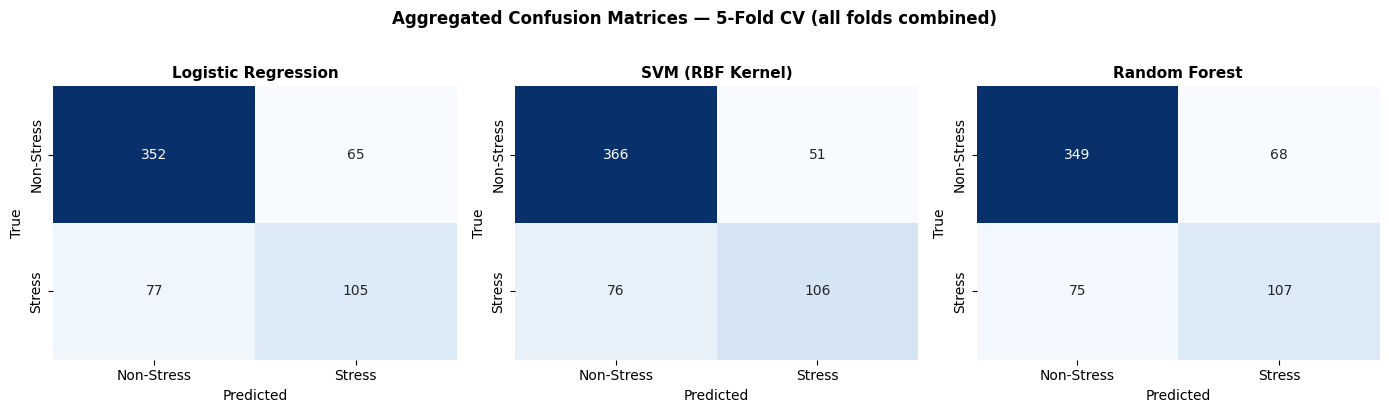

Saved → ../results/figures/cv_confusion_matrices.png


In [9]:
# Step 9 ─ Concatenate y_test + y_pred across all 5 folds → one big CM per model
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, name in zip(axes, MODEL_NAMES):
    yt = np.array(all_y_test[name])
    yp = np.array(all_y_pred[name])
    cm = confusion_matrix(yt, yp)

    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=ax,
        xticklabels=["Non-Stress", "Stress"],
        yticklabels=["Non-Stress", "Stress"],
        cbar=False
    )
    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.suptitle("Aggregated Confusion Matrices — 5-Fold CV (all folds combined)",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../results/figures/cv_confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved → ../results/figures/cv_confusion_matrices.png")

## Step 10 — Aggregated ROC Curve (all folds combined)


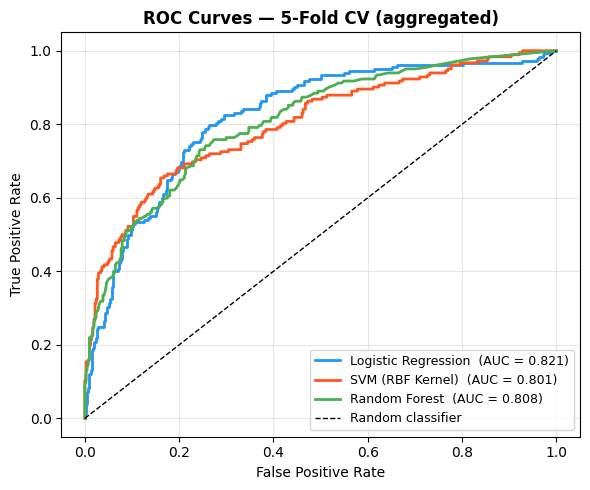

Saved → ../results/figures/cv_roc_curves.png


In [10]:
# Step 10 ─ Concatenate y_test + y_prob across all 5 folds → one ROC curve per model
fig, ax = plt.subplots(figsize=(6, 5))

colors = ["#2196F3", "#FF5722", "#4CAF50"]

for name, color in zip(MODEL_NAMES, colors):
    yt   = np.array(all_y_test[name])
    ypr  = np.array(all_y_prob[name])
    fpr, tpr, _ = roc_curve(yt, ypr)
    roc_val     = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name}  (AUC = {roc_val:.3f})", color=color, lw=2)

ax.plot([0,1],[0,1], "k--", lw=1, label="Random classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — 5-Fold CV (aggregated)", fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../results/figures/cv_roc_curves.png", dpi=300)
plt.show()
print("Saved → ../results/figures/cv_roc_curves.png")

## Step 11 — Save metrics to CSV for the paper


In [11]:
# Step 11 ─ Save both the summary table and the per-fold detail table

# 11a. Summary table (mean ± std as strings — good for pasting into paper)
display_df.to_csv("../results/tables/cv_summary_mean_std.csv")
print("Saved → ../results/tables/cv_summary_mean_std.csv")

# 11b. Raw summary (numeric — useful for further analysis / plotting)
summary_df.to_csv("../results/tables/cv_summary_numeric.csv", index=False)
print("Saved → ../results/tables/cv_summary_numeric.csv")

# 11c. Per-fold detail
detail_df.to_csv("../results/tables/cv_per_fold_detail.csv", index=False)
print("Saved → ../results/tables/cv_per_fold_detail.csv")

print("\nAll result tables saved successfully")

Saved → ../results/tables/cv_summary_mean_std.csv
Saved → ../results/tables/cv_summary_numeric.csv
Saved → ../results/tables/cv_per_fold_detail.csv

All result tables saved successfully


## Step 12 — Results Section Text for the Paper


In [12]:
# Step 12 ─ Auto-generate the Results paragraph using actual numbers
#             Copy the printed output directly into your paper

print("="*80)
print("RESULTS SECTION — paste into paper")
print("="*80)

for name in MODEL_NAMES:
    m = fold_metrics[name]
    acc_m,  acc_s  = np.mean(m["accuracy"]),  np.std(m["accuracy"])
    prec_m, prec_s = np.mean(m["precision"]), np.std(m["precision"])
    rec_m,  rec_s  = np.mean(m["recall"]),    np.std(m["recall"])
    f1_m,   f1_s   = np.mean(m["f1"]),        np.std(m["f1"])
    roc_m,  roc_s  = np.mean(m["roc_auc"]),   np.std(m["roc_auc"])

    print(f"\n{name}:")
    print(
        f"  Accuracy  {acc_m:.3f}±{acc_s:.3f} | Precision {prec_m:.3f}±{prec_s:.3f} | "        f"Recall {rec_m:.3f}±{rec_s:.3f} | F1 {f1_m:.3f}±{f1_s:.3f} | ROC-AUC {roc_m:.3f}±{roc_s:.3f}"
    )

print("\n" + "="*80)
print("PAPER-READY SENTENCE TEMPLATE:")
print("="*80)

# Best model by mean F1
best = max(MODEL_NAMES, key=lambda n: np.mean(fold_metrics[n]["f1"]))
b    = fold_metrics[best]
print(
    f"\nTo evaluate generalisation across subjects, a subject-wise 5-fold "    f"cross-validation was performed on the engineered feature set. "    f"The {best} achieved the highest performance with a mean accuracy of "    f"{np.mean(b['accuracy']):.3f}±{np.std(b['accuracy']):.3f}, "    f"precision of {np.mean(b['precision']):.3f}±{np.std(b['precision']):.3f}, "    f"recall of {np.mean(b['recall']):.3f}±{np.std(b['recall']):.3f}, "    f"F1-score of {np.mean(b['f1']):.3f}±{np.std(b['f1']):.3f}, and "    f"ROC-AUC of {np.mean(b['roc_auc']):.3f}±{np.std(b['roc_auc']):.3f}. "    f"All metrics are reported as mean±standard deviation across 5 folds.")

RESULTS SECTION — paste into paper

Logistic Regression:
  Accuracy  0.763±0.068 | Precision 0.630±0.106 | Recall 0.575±0.193 | F1 0.583±0.131 | ROC-AUC 0.834±0.076

SVM (RBF Kernel):
  Accuracy  0.788±0.071 | Precision 0.653±0.085 | Recall 0.580±0.270 | F1 0.588±0.206 | ROC-AUC 0.836±0.103

Random Forest:
  Accuracy  0.761±0.088 | Precision 0.595±0.141 | Recall 0.585±0.242 | F1 0.576±0.194 | ROC-AUC 0.817±0.109

PAPER-READY SENTENCE TEMPLATE:

To evaluate generalisation across subjects, a subject-wise 5-fold cross-validation was performed on the engineered feature set. The SVM (RBF Kernel) achieved the highest performance with a mean accuracy of 0.788±0.071, precision of 0.653±0.085, recall of 0.580±0.270, F1-score of 0.588±0.206, and ROC-AUC of 0.836±0.103. All metrics are reported as mean±standard deviation across 5 folds.


---

## Feature Importance Analysis

> **Why here and not notebook 13?**  
> Notebook 13 computed importances on a single biased split — same subject in both train and test.  
> Here we use **5-fold averaged RF importances** (leakage-free) and **permutation importance** for all 3 models.


Random Forest — Mean Feature Importance (averaged across 5 folds)
         Feature  Importance      Std
           RMSSD    0.183410 0.030757
 Resp_Regularity    0.141224 0.026374
Resp_Variability    0.136164 0.018034
    HRV_HR_Ratio    0.125719 0.019721
            SDNN    0.121044 0.015515
         Mean_HR    0.075925 0.006224
         Mean_RR    0.075607 0.007522
 Autonomic_Index    0.071902 0.003454
       Resp_Rate    0.069005 0.006231


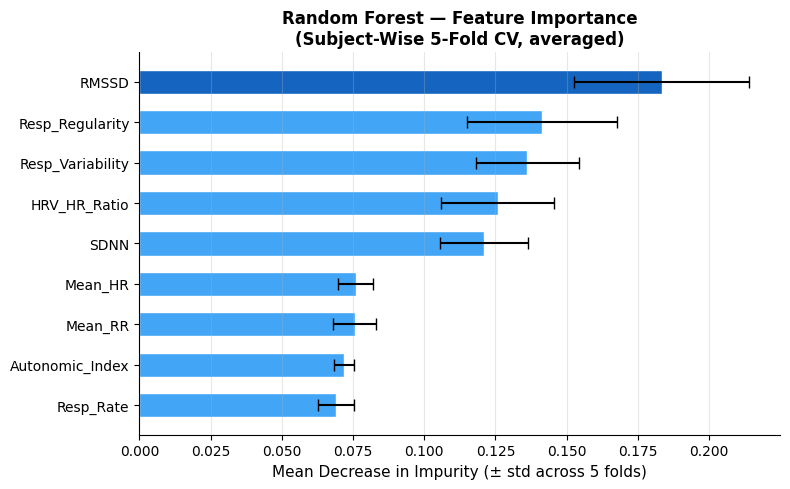

Saved → ../results/figures/rf_feature_importance_cv.png


In [13]:
# ── Random Forest — Average feature importances across all 5 folds ───────────
rf_importance_matrix = np.array(rf_fold_importances)   # shape (5, 9)
mean_importance      = rf_importance_matrix.mean(axis=0)
std_importance       = rf_importance_matrix.std(axis=0)

rf_imp_df = pd.DataFrame({
    "Feature"   : FEATURE_COLS,
    "Importance": mean_importance,
    "Std"       : std_importance
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print("Random Forest — Mean Feature Importance (averaged across 5 folds)")
print(rf_imp_df.to_string(index=False))

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#1565C0" if i == 0 else "#42A5F5" for i in range(len(rf_imp_df))]

ax.barh(
    rf_imp_df["Feature"][::-1],
    rf_imp_df["Importance"][::-1],
    xerr=rf_imp_df["Std"][::-1],
    color=colors[::-1],
    edgecolor="white",
    capsize=4, height=0.6
)
ax.set_xlabel("Mean Decrease in Impurity (± std across 5 folds)", fontsize=11)
ax.set_title("Random Forest — Feature Importance\n(Subject-Wise 5-Fold CV, averaged)",
             fontsize=12, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../results/figures/rf_feature_importance_cv.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved → ../results/figures/rf_feature_importance_cv.png")

In [14]:
# ── Permutation Importance for all 3 models on fold-5 held-out test set ──────
# Uses the same KFold seed — fold 5 is deterministic

fold_splits = list(kf.split(unique_subjects))
tr_idx5, te_idx5 = fold_splits[-1]

train_mask5 = np.isin(subjects, unique_subjects[tr_idx5])
test_mask5  = np.isin(subjects, unique_subjects[te_idx5])

X_tr5 = X_full[train_mask5];  y_tr5 = y_full[train_mask5]
X_te5 = X_full[test_mask5];   y_te5 = y_full[test_mask5]

scaler5  = StandardScaler()
X_tr5    = scaler5.fit_transform(X_tr5)
X_te5    = scaler5.transform(X_te5)

fi_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM (RBF Kernel)"   : SVC(kernel="rbf", probability=True, random_state=42),
    "Random Forest"      : RandomForestClassifier(n_estimators=300, random_state=42),
}

perm_results = {}
for name, model in fi_models.items():
    model.fit(X_tr5, y_tr5)
    result = permutation_importance(
        model, X_te5, y_te5,
        n_repeats=30, random_state=42, scoring="f1"
    )
    perm_results[name] = result
    print(f"  Permutation done: {name}")

print("All permutation importances computed")

  Permutation done: Logistic Regression
  Permutation done: SVM (RBF Kernel)
  Permutation done: Random Forest
All permutation importances computed


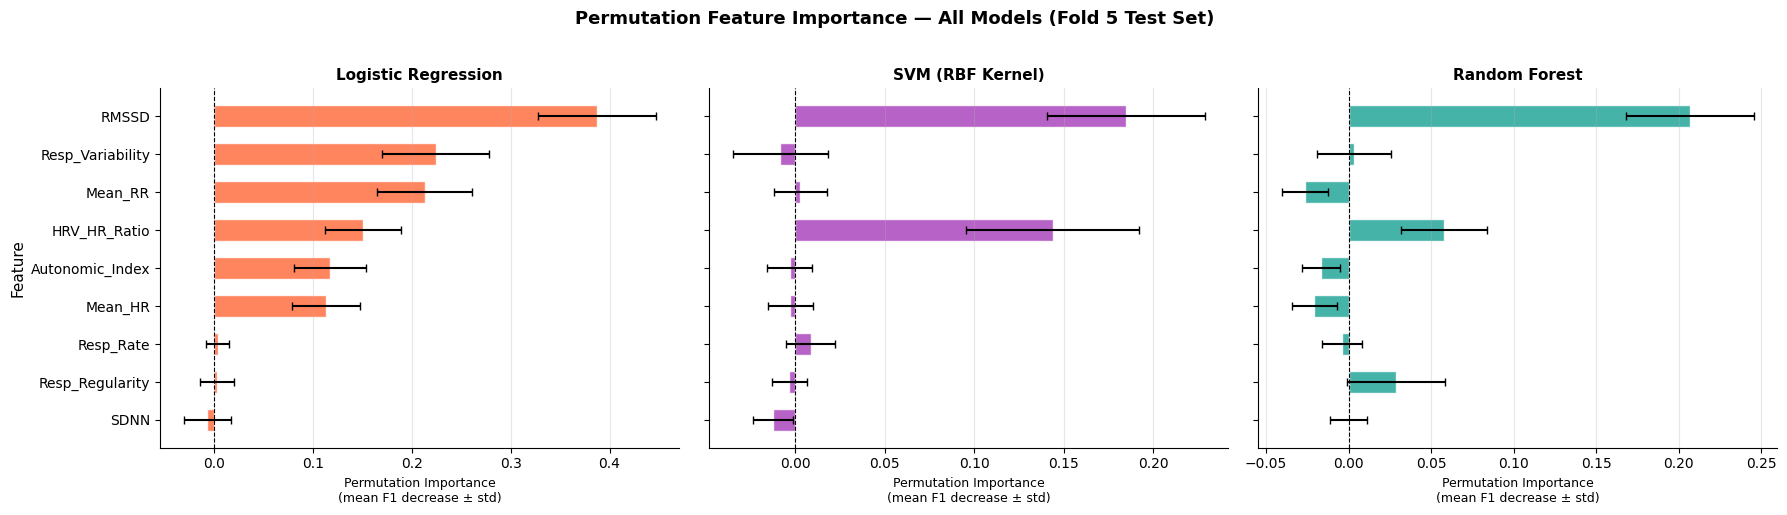

Saved → ../results/figures/permutation_importance_all_models.png


In [15]:
# ── Side-by-side permutation importance bars for all 3 models ────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

palette = {"Logistic Regression": "#FF7043",
           "SVM (RBF Kernel)"   : "#AB47BC",
           "Random Forest"      : "#26A69A"}

perm_dfs = {}
for ax, name in zip(axes, fi_models.keys()):
    result = perm_results[name]
    perm_df = pd.DataFrame({
        "Feature"   : FEATURE_COLS,
        "Importance": result.importances_mean,
        "Std"       : result.importances_std
    }).sort_values("Importance", ascending=False).reset_index(drop=True)
    perm_dfs[name] = perm_df

    ax.barh(
        perm_df["Feature"][::-1],
        perm_df["Importance"][::-1],
        xerr=perm_df["Std"][::-1],
        color=palette[name], alpha=0.85,
        edgecolor="white", capsize=3, height=0.6
    )
    ax.axvline(0, color="black", lw=0.8, linestyle="--")
    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.set_xlabel("Permutation Importance\n(mean F1 decrease ± std)", fontsize=9)
    ax.grid(axis="x", alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)

axes[0].set_ylabel("Feature", fontsize=11)
fig.suptitle("Permutation Feature Importance — All Models (Fold 5 Test Set)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../results/figures/permutation_importance_all_models.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("Saved → ../results/figures/permutation_importance_all_models.png")

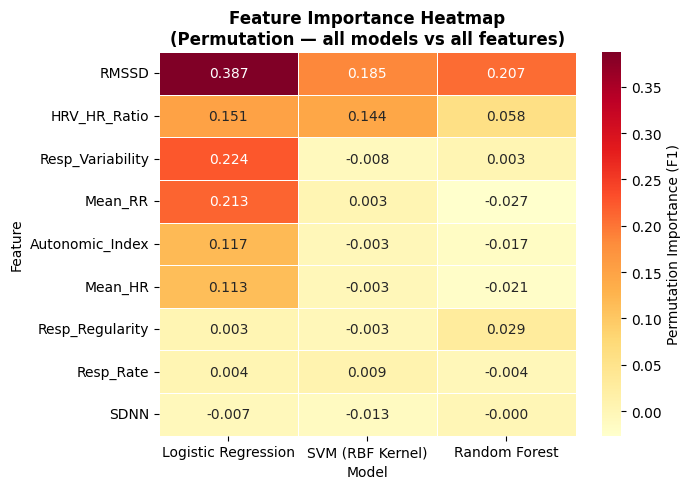

Saved → ../results/figures/feature_importance_heatmap.png


In [16]:
# ── Heatmap: permutation importance — all models × all features ───────────────
heat_data = pd.DataFrame(
    {name: perm_dfs[name].set_index("Feature")["Importance"]
     for name in fi_models.keys()}
)
heat_data["avg"] = heat_data.mean(axis=1)
heat_data = heat_data.sort_values("avg", ascending=False).drop(columns="avg")

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    heat_data, annot=True, fmt=".3f",
    cmap="YlOrRd", linewidths=0.5, ax=ax,
    cbar_kws={"label": "Permutation Importance (F1)"}
)
ax.set_title("Feature Importance Heatmap\n(Permutation — all models vs all features)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Feature")
ax.set_xlabel("Model")
plt.tight_layout()
plt.savefig("../results/figures/feature_importance_heatmap.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("Saved → ../results/figures/feature_importance_heatmap.png")

In [17]:
# ── Save all feature importance results ─────────────────────────────────────

# 1. RF averaged importance
rf_imp_df.to_csv("../results/tables/rf_importance_cv_averaged.csv", index=False)
print("Saved → ../results/tables/rf_importance_cv_averaged.csv")

# 2. RF per-fold importance matrix
rf_fold_df = pd.DataFrame(rf_importance_matrix, columns=FEATURE_COLS)
rf_fold_df.insert(0, "Fold", range(1, 6))
rf_fold_df.to_csv("../results/tables/rf_importance_per_fold.csv", index=False)
print("Saved → ../results/tables/rf_importance_per_fold.csv")

# 3. Permutation importance — one CSV per model
for name, perm_df in perm_dfs.items():
    safe = name.replace(" ","_").replace("(","").replace(")","").replace("/","")
    path = f"../results/tables/perm_importance_{safe}.csv"
    perm_df.to_csv(path, index=False)
    print(f"Saved → {path}")

# 4. Combined heatmap table
heat_data.to_csv("../results/tables/feature_importance_heatmap.csv")
print("Saved → ../results/tables/feature_importance_heatmap.csv")

print("\nAll feature importance files saved successfully")

Saved → ../results/tables/rf_importance_cv_averaged.csv
Saved → ../results/tables/rf_importance_per_fold.csv
Saved → ../results/tables/perm_importance_Logistic_Regression.csv
Saved → ../results/tables/perm_importance_SVM_RBF_Kernel.csv
Saved → ../results/tables/perm_importance_Random_Forest.csv
Saved → ../results/tables/feature_importance_heatmap.csv

All feature importance files saved successfully


In [18]:
# ── Auto-generate paper paragraph ────────────────────────────────────────────
top1 = rf_imp_df.iloc[0]
top2 = rf_imp_df.iloc[1]
top3 = rf_imp_df.iloc[2]
top_overall = heat_data.mean(axis=1).idxmax()

lines = [
    "=" * 70,
    "PAPER-READY PARAGRAPH — Feature Importance (copy into paper)",
    "=" * 70,
    "",
    "Feature importance was assessed using two complementary methods.",
    "For the Random Forest classifier, mean decrease in impurity was averaged",
    "across all five subject-wise cross-validation folds. " +
        top1['Feature'] + " emerged as the most",
    "discriminative feature (importance = " +
        f"{top1['Importance']:.3f} +/- {top1['Std']:.3f}" +
        "), followed by",
    top2['Feature'] + " (" + f"{top2['Importance']:.3f} +/- {top2['Std']:.3f}" + ") and",
    top3['Feature'] + " (" + f"{top3['Importance']:.3f} +/- {top3['Std']:.3f}" + ").",
    "",
    "For all three classifiers, model-agnostic permutation importance was",
    "computed on the fold-5 held-out test set (30 shuffles per feature, F1 criterion).",
    "Across all models, " + top_overall + " ranked as the most influential feature,",
    "corroborating the physiological relationship between autonomic nervous",
    "system activity and psychological stress response.",
]
print("\n".join(lines))

PAPER-READY PARAGRAPH — Feature Importance (copy into paper)

Feature importance was assessed using two complementary methods.
For the Random Forest classifier, mean decrease in impurity was averaged
across all five subject-wise cross-validation folds. RMSSD emerged as the most
discriminative feature (importance = 0.183 +/- 0.031), followed by
Resp_Regularity (0.141 +/- 0.026) and
Resp_Variability (0.136 +/- 0.018).

For all three classifiers, model-agnostic permutation importance was
computed on the fold-5 held-out test set (30 shuffles per feature, F1 criterion).
Across all models, RMSSD ranked as the most influential feature,
corroborating the physiological relationship between autonomic nervous
system activity and psychological stress response.
